# LLM Travel-Itinerary Agent Evaluation Analyses

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter
from pathlib import Path

In [2]:
plt.rcParams.update({
    'figure.figsize': (10, 5.5),
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.autolayout': True,
})

## Data prep

In [3]:
input_path = r'C:/Users/mushj/OneDrive/Desktop/ColumbiaU MSDS/S26 - STATGR5293 - GenAI with LLMs/Final Project/optimized-llm-planning-memory/outputs/consolidated_episode_evals/eval_results-001.csv'
DATA_PATH = Path(input_path)

df = pd.read_csv(DATA_PATH, header=[0])
df.columns = pd.MultiIndex.from_tuples([col.split(".") for col in df.columns])

# cleaner code with MultiIndex columns.
def C(top, sub):
    return (top, sub)

run_col = C('run', 'run_name')
req_col = C('ids', 'request_id')
score_col = C('metrics', 'overall_score')
cost_col = C('det', 'perf_estimated_cost_usd')

# convert known numeric columns after CSV load.
for col in df.columns:
    if col[0] in ['det', 'llm', 'metrics'] or col in [C('episode','total_steps'), C('request','budget_usd'), C('request','duration_days'), C('request','n_destinations'), C('request','n_hard_constraints'), C('request','n_soft_constraints')]:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df[C('episode','success')] = df[C('episode','success')].astype(str).str.lower().map({'true': True, 'false': False})

run_order = df[run_col].dropna().unique().tolist()
print(df.shape)
df.head()

(270, 67)


config                                                        \
        agent_mode   augmentation_id compressor_type         judge_model   
0  mcts_compressor  tgad-trained-001         unknown                none   
1  mcts_compressor  tgad-trained-001         unknown  openai/gpt-4o-mini   
2  mcts_compressor  tgad-trained-001         unknown  openai/gpt-4o-mini   
3  mcts_compressor  tgad-trained-001         unknown  openai/gpt-4o-mini   
4  mcts_compressor  tgad-trained-001         unknown  openai/gpt-4o-mini   

                                                    det  \
  metric_version prompt_id accommodation_coverage_ratio   
0             v3   sweep_D                          0.0   
1             v3   sweep_D                          1.0   
2             v3   sweep_D                          1.0   
3             v3   sweep_D                          1.0   
4             v3   sweep_D                          1.0   

                                                               ...  \
  activity_density_score avg_tool_latency_ms budget_adherence  ...   
0                    0.0            0.355540         0.000000  ...   
1                    0.0            1.795363         0.762194  ...   
2                    0.0            0.954387         1.000000  ...   
3                    0.0            4.132310         1.000000  ...   
4                    0.0            1.545673         0.798892  ...   

          request                                                 \
  complexity_tier duration_days geographic_complexity group_type   
0             low             4            multi_city       solo   
1             low             4           single_city       solo   
2             low             4           single_city       solo   
3             low             9           single_city       solo   
4             low             6            multi_city       solo   

                                                        \
  n_destinations n_hard_constraints n_soft_constraints   
0              2                  5                  3   
1              1                  5                  3   
2              1                  5                  3   
3              1                  5                  3   
4              2                  5                  3   

                                             run            
                   world_id           created_at  run_name  
0  world_67_20260506_141954  2026-05-07 18:00:38  tgad-001  
1  world_62_20260506_141948  2026-05-07 18:00:38  tgad-001  
2  world_66_20260506_141952  2026-05-07 18:00:38  tgad-001  
3  world_56_20260506_141941  2026-05-07 18:00:38  tgad-001  
4  world_71_20260506_141958  2026-05-07 18:00:38  tgad-001  

[5 rows x 67 columns]

## Helper functions

In [4]:
def grouped_mean(metric):
    return df.groupby(run_col)[metric].mean().sort_values(ascending=False)

def ci95(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return np.nan
    return 1.96 * x.std(ddof=1) / np.sqrt(len(x))

# * Leaderboard by run_name

In [5]:
leader = df.groupby(run_col).agg(
    overall_mean=(score_col, 'mean'),
    overall_median=(score_col, 'median'),
    overall_std=(score_col, 'std'),
    overall_ci95=(score_col, ci95),
    success_rate=(C('episode','success'), 'mean'),
    completion_mean=(C('det','completion_rate'), 'mean'),
    hard_constraint_mean=(C('det','hard_constraint_ratio'), 'mean'),
    n=(score_col, 'size')
).sort_values('overall_mean', ascending=False)

display(leader.round(4))

,overall_mean,overall_median,overall_std,overall_ci95,success_rate,completion_mean,hard_constraint_mean,n
"(run, run_name)",,,,,,,,
tgad-001,0.3506,0.3077,0.1587,0.0328,0.2556,0.1804,0.0889,90
sweep_D-baseline-001,0.2272,0.1667,0.1150,0.0237,0.0444,0.0425,0.0222,90
default-baseline-001,0.2265,0.1667,0.1283,0.0265,0.0111,0.0403,0.0244,90


In [6]:
# y_col = ('det', 'hard_constraint_ratio')
y_col = ('metrics', 'overall_score')

_g, _y = 'run', y_col[1]

plot_df = df[[run_col, y_col]]
plot_df.columns = [_g, _y]

group_ids = sorted(plot_df[_g].unique())

grouped_df = [
    plot_df[plot_df[_g] == group][_y].values
    for group in group_ids
]

labels = group_ids

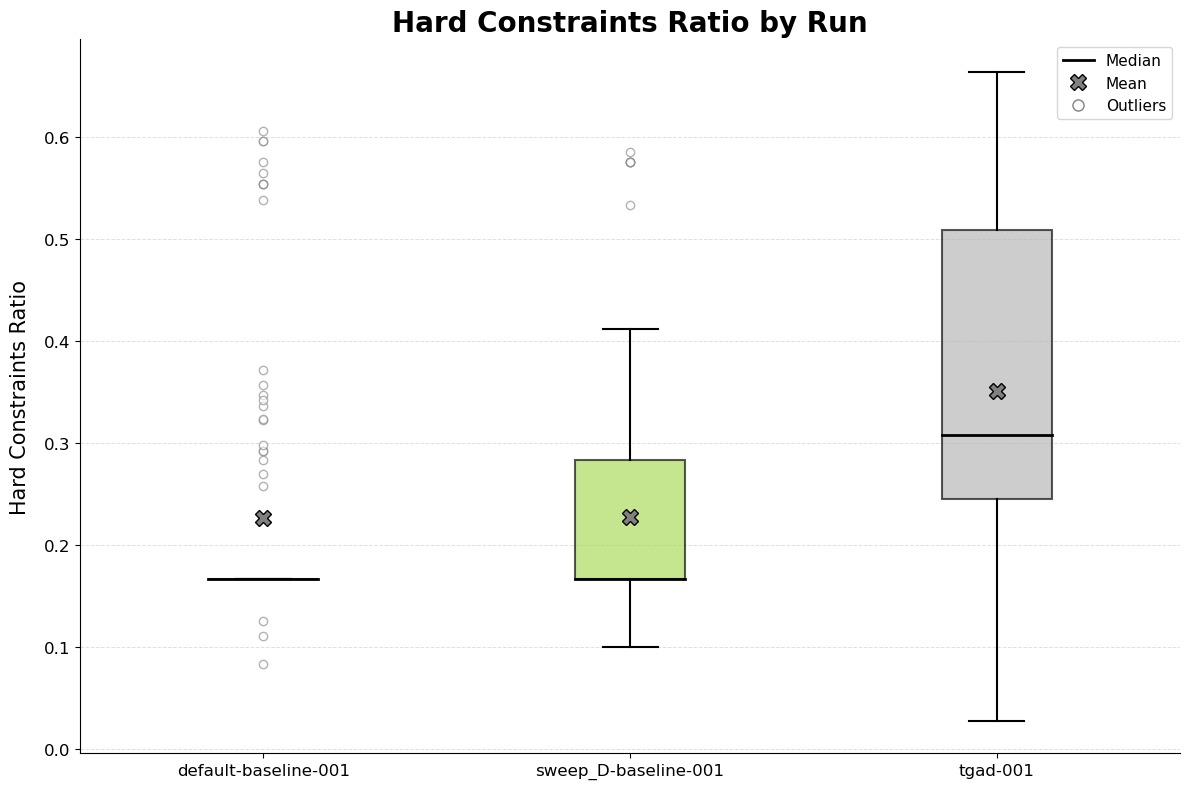

In [7]:
fig, ax = plt.subplots(figsize=(12, 8))

box = ax.boxplot(grouped_df, labels=labels, patch_artist=True, showmeans=True, meanprops=dict(marker='X', markerfacecolor='gray', markeredgecolor='black', markersize=12), medianprops=dict(color='black', linewidth=2), boxprops=dict(linewidth=1.5), whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5), flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='gray', markersize=6, alpha=0.6))

colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
    patch.set_edgecolor('black')

ax.set_title(f'{_y} Distribution by {_g}', fontsize=20, weight='bold', pad=20)
ax.set_xlabel(_g, fontsize=15, labelpad=10)
ax.set_ylabel(_y, fontsize=15, labelpad=10)
ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)

legend_elements = [
    Line2D([0], [0], color='black', linewidth=2, label='Median'),
    Line2D([0], [0], marker='X', color='w', label='Mean', markerfacecolor='gray', markeredgecolor='black', markersize=12),
    Line2D([0], [0], marker='o', color='w', label='Outliers', markerfacecolor='white', markeredgecolor='gray', markersize=8)
]

ax.set_title('Hard Constraints Ratio by Run', fontweight='bold', size=20)
ax.set_ylabel('Hard Constraints Ratio')
ax.set_xlabel('')
ax.legend(handles=legend_elements, fontsize=11, frameon=True, loc='best')
plt.tight_layout()
plt.show()

# * Performance-cost Pareto frontier

In [8]:
pareto = df.groupby(run_col).agg(mean_score=(score_col,'mean'), mean_cost=(cost_col,'mean')).reset_index()

# A run is dominated if another has >= score and <= cost, with one strict improvement.
def dominated(row):
    others = pareto[pareto[run_col] != row[run_col]]
    return ((others['mean_score'] >= row['mean_score']) & (others['mean_cost'] <= row['mean_cost']) & ((others['mean_score'] > row['mean_score']) | (others['mean_cost'] < row['mean_cost']))).any()

pareto['dominated'] = pareto.apply(dominated, axis=1)
display(pareto.sort_values(['dominated','mean_score'], ascending=[True,False]).round(4))

,"(run, run_name)",mean_score,mean_cost,dominated
2,tgad-001,0.3506,0.0843,False
1,sweep_D-baseline-001,0.2272,0.0023,False
0,default-baseline-001,0.2265,0.0032,True


,"(run, run_name)",mean_score,mean_cost,dominated
2,tgad-001,0.3506,0.0843,False
1,sweep_D-baseline-001,0.2272,0.0023,False
0,default-baseline-001,0.2265,0.0032,True


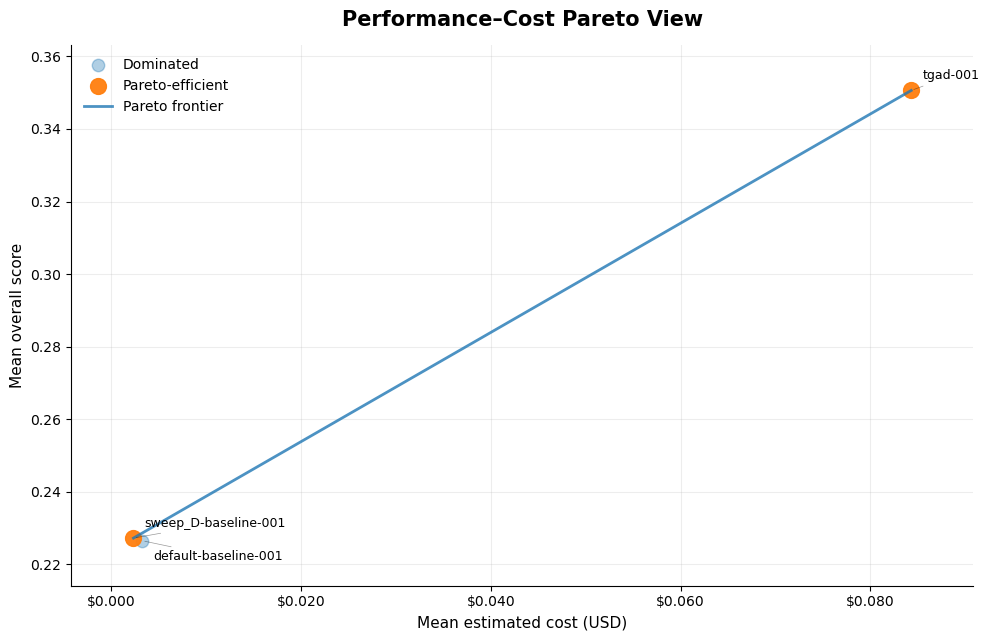

In [9]:
pareto = (
    df.groupby(run_col)
      .agg(mean_score=(score_col, "mean"), mean_cost=(cost_col, "mean"))
      .reset_index()
)

def dominated(row):
    others = pareto[pareto[run_col] != row[run_col]]
    return (
        (others["mean_score"] >= row["mean_score"])
        & (others["mean_cost"] <= row["mean_cost"])
        & ((others["mean_score"] > row["mean_score"]) | (others["mean_cost"] < row["mean_cost"]))
    ).any()

pareto["dominated"] = pareto.apply(dominated, axis=1)

display(
    pareto.sort_values(["dominated", "mean_score"], ascending=[True, False]).round(4)
)

frontier = pareto[~pareto["dominated"]].sort_values("mean_cost")

fig, ax = plt.subplots(figsize=(10, 6.5))

dom = pareto[pareto["dominated"]]
nondom = pareto[~pareto["dominated"]]

ax.scatter(dom["mean_cost"], dom["mean_score"], s=80, alpha=0.35, label="Dominated")
ax.scatter(nondom["mean_cost"], nondom["mean_score"], s=130, alpha=0.95, label="Pareto-efficient")

if len(frontier) > 1:
    ax.plot(frontier["mean_cost"], frontier["mean_score"], linewidth=2, alpha=0.8, label="Pareto frontier")

for i, (_, r) in enumerate(pareto.sort_values("mean_cost").iterrows()):
    offset_y = 8 if i % 2 == 0 else -14
    ax.annotate(
        r[run_col],
        xy=(r["mean_cost"], r["mean_score"]),
        xytext=(8, offset_y),
        textcoords="offset points",
        fontsize=9,
        arrowprops=dict(arrowstyle="-", lw=0.5, alpha=0.4),
    )

ax.set_title("Performance–Cost Pareto View", fontsize=15, pad=14, fontweight='bold')
ax.set_xlabel("Mean estimated cost (USD)", fontsize=11)
ax.set_ylabel("Mean overall score", fontsize=11)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.3f}"))

ax.grid(True, alpha=0.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

x_pad = (pareto["mean_cost"].max() - pareto["mean_cost"].min()) * 0.08
y_pad = (pareto["mean_score"].max() - pareto["mean_score"].min()) * 0.10

ax.set_xlim(pareto["mean_cost"].min() - x_pad, pareto["mean_cost"].max() + x_pad)
ax.set_ylim(pareto["mean_score"].min() - y_pad, pareto["mean_score"].max() + y_pad)

plt.tight_layout()
plt.show()

# * Latency-performance trade-off

In [10]:
# x_col = ('det','perf_episode_wall_time_ms')
x_col = ('det','perf_total_llm_latency_ms')
x_col = ('det','avg_tool_latency_ms')

# y_col = ('det', 'hard_constraint_ratio')
y_col = ('metrics', 'overall_score')

plot_df = (
    df[[run_col, x_col, y_col]]
    .dropna()
    .copy()
)
_g, _x, _y = 'run', x_col[1], y_col[1]
plot_df.columns = [_g, _x, _y]

group_means = (
    plot_df
    .groupby(_g)[[_x, _y]]
    .mean()
    .reset_index()
)
group_means

,run,avg_tool_latency_ms,overall_score
0,default-baseline-001,1.074996,0.226476
1,sweep_D-baseline-001,0.750936,0.227197
2,tgad-001,2.156649,0.350622


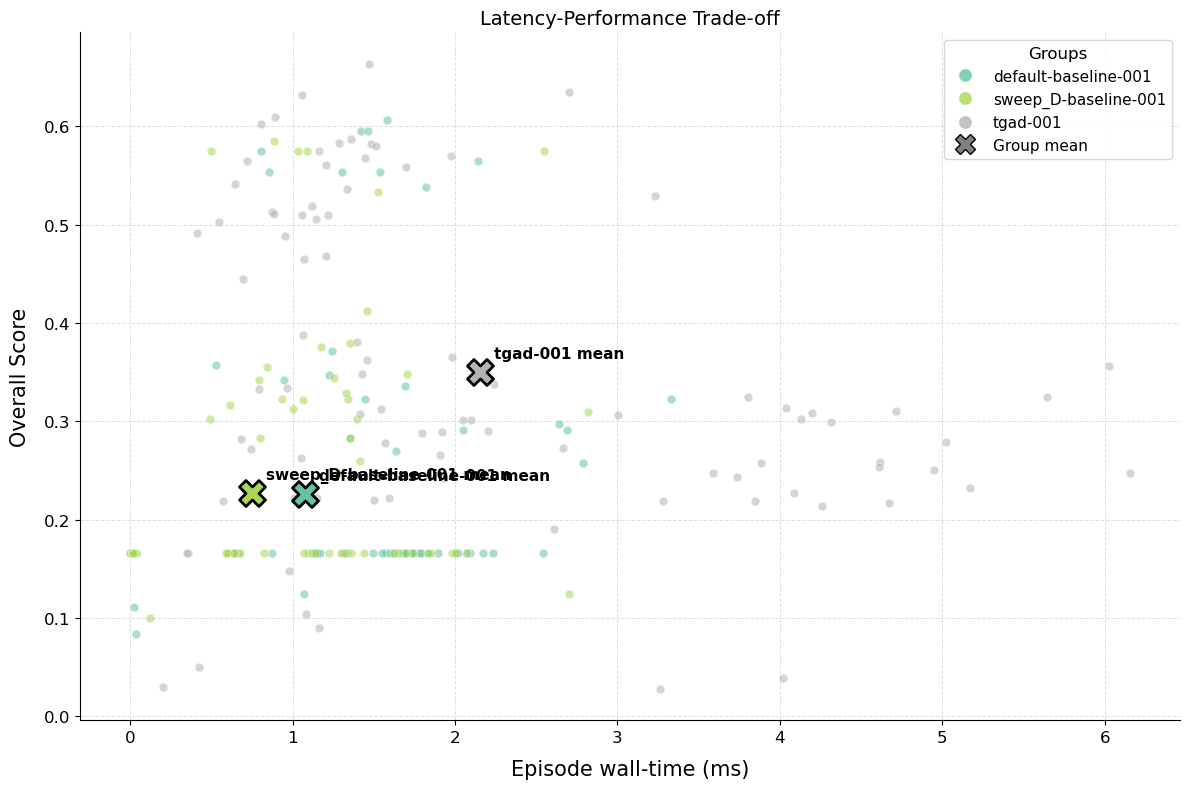

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# qualitative colormap
groups = sorted(plot_df[_g].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(groups)))

for color, group in zip(colors, groups):
    subset = plot_df[plot_df[_g] == group]
    
    ax.scatter(
        subset[_x], subset[_y],
        s=40, alpha=0.55, color=color, edgecolor='white',
        linewidth=0.6, label=f'{group} observations'
    )

    # Mean point
    mean_row = group_means[group_means[_g] == group]

    ax.scatter(
        mean_row[_x], mean_row[_y],
        s=350, color=color, edgecolor='black', linewidth=2,
        marker='X', zorder=10
    )

    # Annotate mean
    ax.annotate(
        f'{group} mean',
        (mean_row[_x].values[0], mean_row[_y].values[0]),
        xytext=(10, 10), textcoords='offset points',
        fontsize=11, weight='bold'
    )

ax.set_title(f'{_x} vs {_y} by {_g}', fontsize=20, weight='bold', pad=20)
ax.set_xlabel(_x, fontsize=15, labelpad=10)
ax.set_ylabel(_y, fontsize=15, labelpad=10)
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)

legend_elements = []
for color, group in zip(colors, groups):
    legend_elements.append(
        Line2D([0], [0], marker='o', color='w', label=f'{group}',
            markerfacecolor=color, markersize=10, alpha=0.8))

legend_elements.append(
    Line2D([0], [0], marker='X', color='w',
        label='Group mean',
        markerfacecolor='gray', markeredgecolor='black', markersize=14))

ax.legend(
    handles=legend_elements, title='Groups',
    fontsize=11, title_fontsize=12, frameon=True, loc='best'
)
ax.set_title('Latency-Performance Trade-off')
ax.set_xlabel('Episode wall-time (ms)')
ax.set_ylabel('Overall Score')
plt.tight_layout()
plt.show()

# * Paired statistical tests

In [12]:
from itertools import combinations
try:
    from scipy import stats
    has_scipy = True
except Exception:
    has_scipy = False
paired = df.pivot_table(index=[req_col], columns=[run_col], values=[score_col], aggfunc='mean').dropna()
rows = []

for a, b in combinations(paired.columns, 2):
    diff = paired[a] - paired[b]
    row = {'run_a': a, 'run_b': b, 'mean_delta_a_minus_b': diff.mean(), 'median_delta': diff.median(), 'n_pairs': diff.notna().sum()}
    if has_scipy:
        row['paired_t_pvalue'] = stats.ttest_rel(paired[a], paired[b], nan_policy='omit').pvalue
        try:
            row['wilcoxon_pvalue'] = stats.wilcoxon(diff.dropna()).pvalue
        except ValueError:
            row['wilcoxon_pvalue'] = np.nan
    else:
        row['paired_t_pvalue'] = np.nan
        row['wilcoxon_pvalue'] = np.nan
    rows.append(row)
tests = pd.DataFrame(rows).sort_values('paired_t_pvalue')
display(tests.round(6))

,run_a,run_b,mean_delta_a_minus_b,median_delta,n_pairs,paired_t_pvalue,wilcoxon_pvalue
2,"(metrics, overall_score, sweep_D-baseline-001)","(metrics, overall_score, tgad-001)",-0.123425,-0.101782,90,0.000000,0.000001
1,"(metrics, overall_score, default-baseline-001)","(metrics, overall_score, tgad-001)",-0.124146,-0.108381,90,0.000000,0.000000
0,"(metrics, overall_score, default-baseline-001)","(metrics, overall_score, sweep_D-baseline-001)",-0.000722,0.000000,90,0.966201,0.697415


#### Wilcoxon signed-rank test

A nonparametric paired test.

It tests whether the distribution of paired differences is centered around zero, without assuming normality.

# * Metric decomposition heatmap

,hard_constraint_ratio,completion_rate,budget_adherence,logical_consistency,tool_efficiency,soft_constraint_score,constraint_adherence,feasibility,creativity
"(run, run_name)",,,,,,,,,
default-baseline-001,0.024,0.040,0.177,0.244,0.957,0.008,0.307,0.489,0.068
sweep_D-baseline-001,0.022,0.043,0.182,0.289,0.975,0.012,0.173,0.519,0.029
tgad-001,0.089,0.180,0.641,0.894,0.347,0.074,0.282,0.573,0.085


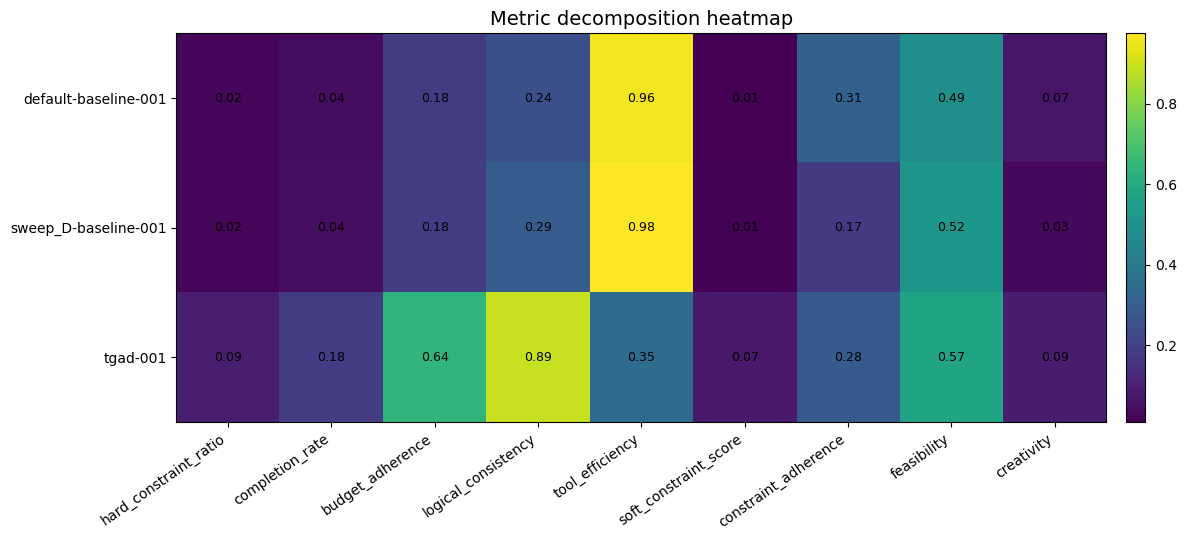

In [13]:
metric_cols = [
    C('det','hard_constraint_ratio'), 
    C('det','completion_rate'), 
    C('det','budget_adherence'), 
    C('det','logical_consistency'), 
    C('det','tool_efficiency'), 
    C('det','soft_constraint_score'),
    C('llm','constraint_adherence'), 
    C('llm','feasibility'), 
    C('llm','creativity')
]

heat = df.groupby(run_col)[metric_cols].mean()
heat.columns = [c[1] for c in heat.columns]
display(heat.round(3))
fig, ax = plt.subplots(figsize=(12, 5.5))
im = ax.imshow(heat.values, aspect='auto')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=35, ha='right')
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_title('Metric decomposition heatmap')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
plt.show()

## 13. Empty-itinerary inflation check

In [14]:
inflation = df[(df[C('det','completion_rate')] < 0.55) & (df[C('det','budget_adherence')] > 0.85) & (df[C('det','logical_consistency')] > 0.85)]
summary = inflation.groupby(run_col).size().reindex(run_order).fillna(0).astype(int).to_frame('potential_inflation_cases')
summary['rate'] = summary['potential_inflation_cases'] / df.groupby(run_col).size()
display(summary.sort_values('rate', ascending=False))

display(inflation[[run_col, req_col, C('det','completion_rate'), C('det','budget_adherence'), C('det','logical_consistency'), score_col]].head(20))

,potential_inflation_cases,rate
"(run, run_name)",,
tgad-001,40,0.444444
sweep_D-baseline-001,13,0.144444
default-baseline-001,12,0.133333


run                                   ids             det  \
    run_name                            request_id completion_rate   
2   tgad-001  fe2149e8-fab5-4b5d-8302-3eb29aba9935        0.250000   
3   tgad-001  fdaa3159-f74f-4c53-9b5b-c1186e323cfc        0.111111   
5   tgad-001  eee7cdf9-3539-4db2-bc64-7c803ce306d8        0.111111   
7   tgad-001  f1ec8314-ae7d-41dd-b24a-9bcf02ac6169        0.166667   
10  tgad-001  d50cbaf4-b449-41c8-9029-ffb7d37e29d0        0.250000   
13  tgad-001  d6af3eda-e82a-4bc0-a45c-d70dcf10374e        0.250000   
14  tgad-001  e6abac6d-2739-4836-9e0b-e58f92fb034b        0.111111   
15  tgad-001  d5008ebf-cf45-4111-a863-6d67d05c7b57        0.111111   
17  tgad-001  c64e928a-f36e-43f4-b6d9-ecebc272adfe        0.111111   
19  tgad-001  c447633d-89d0-4a8e-8153-300aa50f56dd        0.166667   
25  tgad-001  b11e2c7d-1eb7-4f35-a7f7-eb9f489ceb35        0.250000   
31  tgad-001  a221ab6a-e55f-4d07-b54d-b26e92834f56        0.111111   
32  tgad-001  9e11e386-def3-46ca-a3ac-05bb767e0a83        0.500000   
33  tgad-001  9ba9ae0c-e836-4536-a0b9-8729de7c7374        0.250000   
37  tgad-001  8a9811a0-370b-4510-b0d1-e059db103a31        0.111111   
39  tgad-001  82fcf004-2e09-4992-9c16-d625b9fbbf6d        0.250000   
43  tgad-001  7af11e87-fc6e-4b59-8d13-5584e25cc1df        0.166667   
45  tgad-001  7b14abbd-3afc-48a5-b088-e80a2cf7d39a        0.500000   
46  tgad-001  655c0007-5556-438f-ba8a-850589175aa3        0.250000   
47  tgad-001  641af254-53e6-4c82-9e8a-cb100508580e        0.500000   

                                              metrics  
   budget_adherence logical_consistency overall_score  
2          1.000000                 1.0      0.488889  
3          1.000000                 1.0      0.302778  
5          0.976387                 1.0      0.337616  
7          1.000000                 1.0      0.348148  
10         1.000000                 1.0      0.509722  
13         1.000000                 1.0      0.468056  
14         1.000000                 1.0      0.519444  
15         0.986468                 1.0      0.325261  
17         1.000000                 1.0      0.509722  
19         1.000000                 1.0      0.558333  
25         1.000000                 1.0      0.541787  
31         1.000000                 1.0      0.568056  
32         1.000000                 1.0      0.465278  
33         1.000000                 1.0      0.512500  
37         0.949644                 1.0      0.324970  
39         1.000000                 1.0      0.602778  
43         1.000000                 1.0      0.387500  
45         1.000000                 1.0      0.663889  
46         1.000000                 1.0      0.536111  
47         1.000000                 1.0      0.587500